# Appendix 2: Classification of Compact One-Manifolds

**Source Span.** `Differential Topology.pdf` printed pages `208-211` only. Bibliography and index pages are intentionally excluded. The appendix proves the compact one-manifold classification using Morse functions, interval pieces, closure behavior, forbidden local branching, maximal chains, circle-versus-interval endpoint cases, and a smoothing lemma.

**Appendix Goal.** Learn why every connected compact one-dimensional manifold with boundary is modeled by either a closed interval or a circle. If the manifold is disconnected, each connected component is one of those two types. The proof turns smooth one-dimensional geometry into a finite incidence graph: cut at a finite set of special points, treat the remaining open intervals as edges, and use the local one-manifold condition to force every vertex to have degree one or two.

This notebook is a proof scaffold, not a copied proof. It visualizes the smoothing lemma as a positive-derivative repair, shows Morse cuts on interval and circle models, maps a component monotonically to an open interval, rejects forbidden branch points, and classifies the finite incidence graph as a path or cycle. The final checks are deliberately combinatorial because the appendix's argument becomes combinatorial after the smooth cuts are made.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the Differential Topology course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html

UNIT_KEY = "appendix-2-classification-of-compact-one-manifolds"
UNIT_TITLE = "Classification of Compact One-Manifolds"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
TRACKED_ARTIFACTS = []
np.set_printoptions(precision=5, suppress=True)
print(f"Book root: {BOOK_ROOT}")


Book root: D:\Geometry\Differential-Topology


## Visual Storyboard

1. **Smoothing lemma derivative repair.** A piecewise monotone coordinate function is replaced by a smooth monotone function with positive derivative. The learner inspects endpoint agreement and derivative positivity.
2. **Morse cuts into interval pieces.** A circle and an interval are cut at boundary and critical points. Removing the finite set leaves open intervals.
3. **Open interval coordinate on a component.** One component is mapped monotonically to an interval; inverse consistency and positive derivative are checked.
4. **Forbidden local models.** A branch point with three incident arcs is contrasted with legal line and half-line neighborhoods. The graph degree test rules out the branch.
5. **Chain-cycle classifier.** The finite incidence graph has vertices from the cut set and edges from interval components. Connected graphs with all degrees at most two are paths or cycles; degree-one vertices mark interval endpoints, while all degree-two vertices mark a circle.

## Library Routing

| Concept | Representation | Library | Why this route is used | Check |
| --- | --- | --- | --- | --- |
| Smoothing lemma | Positive derivative and integrated coordinate plot | NumPy + Matplotlib | The lemma is about repairing a one-dimensional coordinate map | minimum derivative positive and endpoint values match |
| Morse cuts | Interval/circle diagrams with finite cut set | Matplotlib | The classification starts by cutting into open intervals | finite set count and component count recorded |
| Component coordinate | Monotone map and inverse sampling | Plotly + NumPy | An open interval component is best inspected as a one-variable coordinate | derivative positive and inverse residual small |
| Forbidden branching | Incidence graph degrees | NetworkX + Matplotlib | The proof becomes a finite graph classifier | max degree at most two for legal one-manifold models |
| Path/cycle classification | Connected path/cycle graphs | NetworkX + CSV/JSON | Endpoint pattern distinguishes interval and circle | legal connected graph classified as path or cycle |


## Smoothing A Monotone Coordinate

The appendix uses a smoothing lemma to replace a piecewise-smooth monotone coordinate by a smooth coordinate without losing positivity of the derivative. In one dimension, this is the exact repair needed after assembling local interval coordinates across cut points. The important invariant is not the particular formula; it is that the repaired derivative stays positive, so the resulting map is still locally a diffeomorphism.

The model below starts with a positive derivative that changes rapidly near a joining point. A smooth bump-like transition produces a repaired derivative, and integrating it gives a monotone coordinate. The code rescales the coordinate so the endpoint values match the interval endpoints. The saved check records the minimum derivative and endpoint residuals. This is the analytic piece that lets the graph-level classification return to smooth diffeomorphisms.


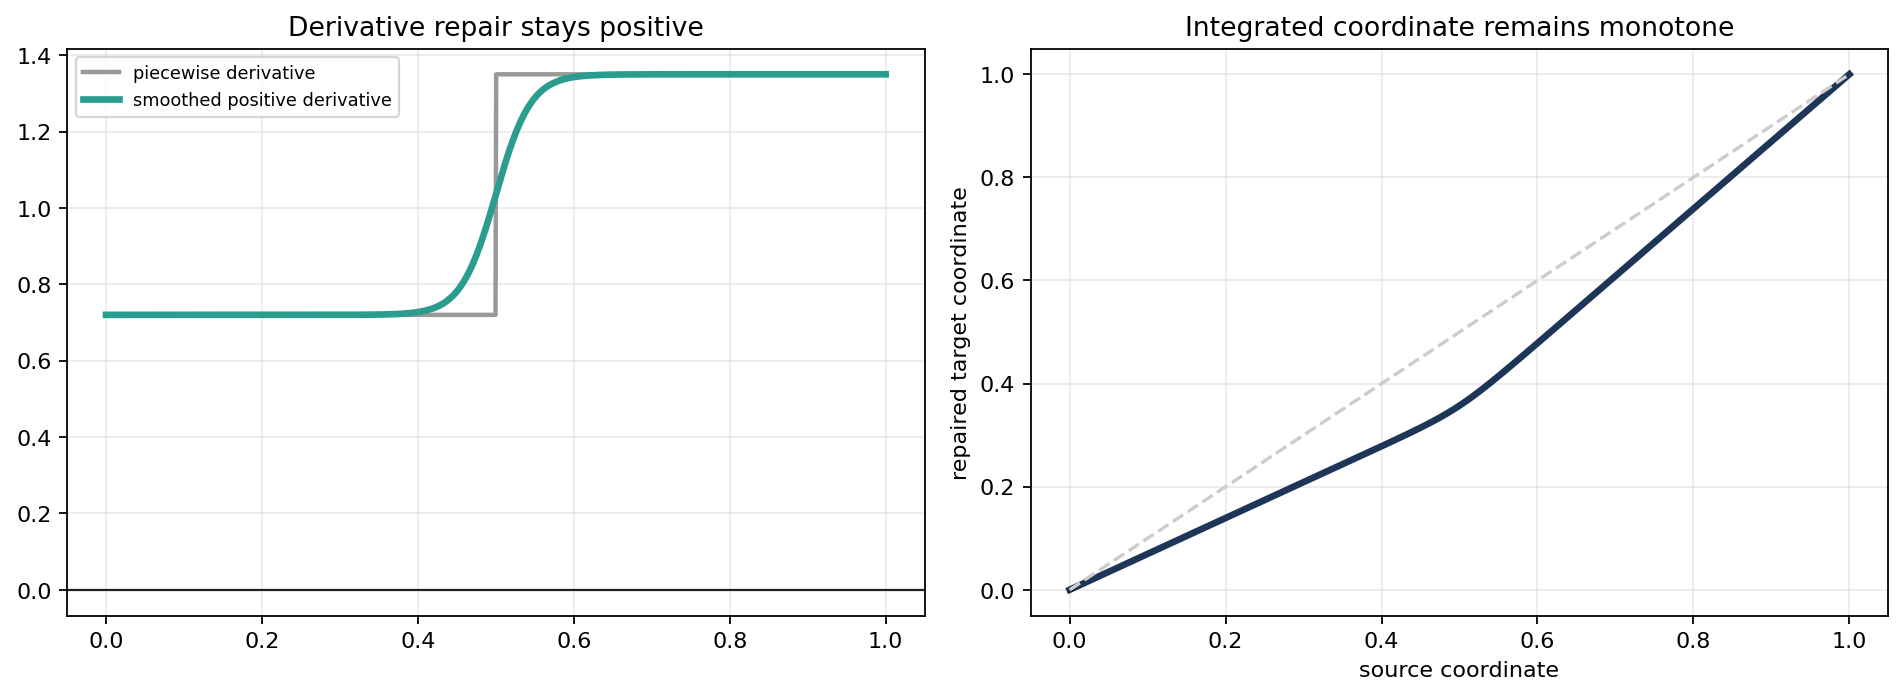

{'minimum_derivative': 0.7200000001407187,
 'endpoint_residual': 0.0,
 'strictly_positive': True,
 'monotone': True}

In [2]:
t = np.linspace(0, 1, 1200)
raw_derivative = np.where(t < 0.5, 0.72, 1.35)
transition = 0.5 * (1 + np.tanh((t - 0.5) / 0.045))
smooth_derivative = 0.72 * (1 - transition) + 1.35 * transition
coord = np.zeros_like(t)
coord[1:] = np.cumsum(0.5 * (smooth_derivative[1:] + smooth_derivative[:-1]) * np.diff(t))
coord = coord / coord[-1]
min_derivative = float(smooth_derivative.min())
endpoint_residual = float(abs(coord[0]) + abs(coord[-1] - 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(t, raw_derivative, color="#999999", lw=2, label="piecewise derivative")
axes[0].plot(t, smooth_derivative, color="#2a9d8f", lw=3, label="smoothed positive derivative")
axes[0].axhline(0, color="#222222", lw=1)
axes[0].set_title("Derivative repair stays positive")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)
axes[1].plot(t, coord, color="#1d3557", lw=3)
axes[1].plot([0, 1], [0, 1], color="#cccccc", ls="--")
axes[1].set_title("Integrated coordinate remains monotone")
axes[1].set_xlabel("source coordinate")
axes[1].set_ylabel("repaired target coordinate")
axes[1].grid(alpha=0.25)
fig.tight_layout()
smooth_path = save_matplotlib(fig, FIGURES / "smoothing-lemma-derivative-repair.png")
plt.close(fig)
smooth_check = {"minimum_derivative": min_derivative, "endpoint_residual": endpoint_residual, "strictly_positive": min_derivative > 0, "monotone": bool(np.all(np.diff(coord) > 0))}
smooth_json = save_json(smooth_check, CHECKS / "smoothing-lemma-derivative-repair.json")
TRACKED_ARTIFACTS.extend([smooth_path, smooth_json])
display_artifact(smooth_path, width=840)
smooth_check


## Morse Cuts And Open Interval Components

A Morse function on a compact one-manifold has finitely many critical points, and a manifold with boundary also contributes boundary points. Remove that finite set. What remains is a finite collection of open intervals. Each interval component has a coordinate in which the Morse function is monotone, so it behaves like a standard open interval. The closure of such a component can add at most two points from the cut set.

The figure shows this for a circle cut at two critical points and an interval cut at its endpoints plus one interior critical point. The exact height functions are not important; the incidence pattern is. Components are edges, special points are vertices, and the one-manifold local model says no vertex can have three or more incident edges. That observation drives the entire classification.


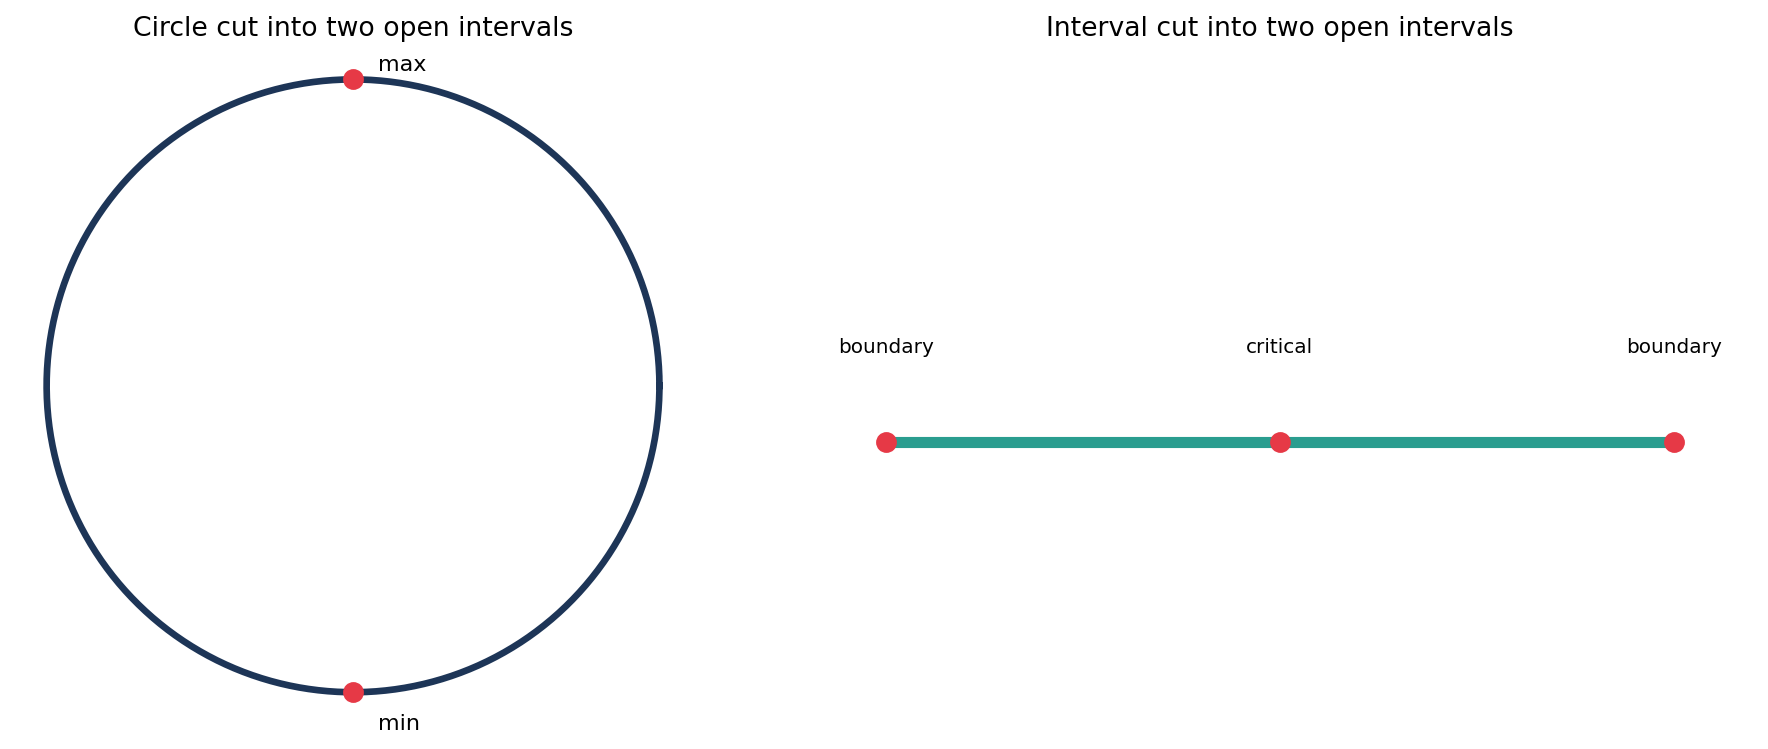

[{'model': 'circle height',
  'cut_points': 2,
  'open_interval_components': 2,
  'boundary_points': 0},
 {'model': 'closed interval with one interior critical point',
  'cut_points': 3,
  'open_interval_components': 2,
  'boundary_points': 2}]

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
# Circle with two cut points.
th = np.linspace(0, 2*np.pi, 400)
axes[0].plot(np.cos(th), np.sin(th), color="#1d3557", lw=3)
cut_circle = [(0, 1), (0, -1)]
axes[0].scatter([p[0] for p in cut_circle], [p[1] for p in cut_circle], color="#e63946", s=70, zorder=3, label="critical set S")
axes[0].text(0.08, 1.03, "max")
axes[0].text(0.08, -1.12, "min")
axes[0].set_title("Circle cut into two open intervals")
axes[0].set_aspect("equal", adjustable="box")
axes[0].axis("off")
# Interval with endpoints and one interior cut.
axes[1].plot([0, 1], [0, 0], color="#2a9d8f", lw=5)
cut_interval = [0, 0.5, 1]
axes[1].scatter(cut_interval, [0, 0, 0], color="#e63946", s=70, zorder=3)
for x0, label in zip(cut_interval, ["boundary", "critical", "boundary"]):
    axes[1].text(x0, 0.08, label, ha="center", fontsize=9)
axes[1].set_xlim(-0.1, 1.1)
axes[1].set_ylim(-0.25, 0.35)
axes[1].set_title("Interval cut into two open intervals")
axes[1].axis("off")
fig.tight_layout()
cut_path = save_matplotlib(fig, FIGURES / "morse-cut-components.png")
plt.close(fig)
cut_rows = [
    {"model": "circle height", "cut_points": 2, "open_interval_components": 2, "boundary_points": 0},
    {"model": "closed interval with one interior critical point", "cut_points": 3, "open_interval_components": 2, "boundary_points": 2},
]
cut_csv = save_csv(cut_rows, TABLES / "morse-cut-components.csv")
cut_json = save_json({"rows": cut_rows}, CHECKS / "morse-cut-components.json")
TRACKED_ARTIFACTS.extend([cut_path, cut_csv, cut_json])
display_artifact(cut_path, width=840)
cut_rows


## A Component Looks Like An Open Interval

After the cut, each component carries a monotone coordinate. In the proof, the Morse function supplies that coordinate away from critical points. The image is an open interval, and the inverse function theorem says the coordinate is locally invertible wherever the derivative is nonzero. The small lab below uses a monotone smooth function on one component and samples its inverse numerically.

This is the local-to-global handoff. Locally every component looks like an interval. Globally we must decide how the closures of those intervals attach to the finite cut set. The next section turns that attachment data into a graph.


In [4]:
s = np.linspace(-1, 1, 600)
component_map = s + 0.18*np.sin(np.pi*s)
derivative = 1 + 0.18*np.pi*np.cos(np.pi*s)
# Numerical inverse by interpolation on monotone samples.
y_samples = np.linspace(component_map.min(), component_map.max(), 80)
s_inverse = np.interp(y_samples, component_map, s)
roundtrip = np.interp(s_inverse, s, component_map)
inverse_residual = float(np.max(np.abs(roundtrip - y_samples)))
component_check = {"minimum_derivative": float(derivative.min()), "inverse_residual": inverse_residual, "monotone": bool(np.all(np.diff(component_map) > 0))}
fig = go.Figure()
fig.add_trace(go.Scatter(x=s, y=component_map, mode="lines", line=dict(color="#1d3557", width=3), name="component coordinate"))
fig.add_trace(go.Scatter(x=s, y=derivative, mode="lines", line=dict(color="#e76f51", width=2), name="derivative"))
fig.add_hline(y=0, line_color="#444444", line_width=1)
fig.update_layout(title="Open interval component: monotone coordinate and positive derivative", xaxis_title="component parameter", yaxis_title="value", width=760, height=520)
component_html = save_plotly_html(fig, HTML / "component-open-interval-coordinate.html")
component_json = save_json(component_check, CHECKS / "component-open-interval-coordinate.json")
TRACKED_ARTIFACTS.extend([component_html, component_json])
display_artifact(component_html, width=800, height=520)
component_check


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'minimum_derivative': 0.4345133223538372,
 'inverse_residual': 5.551115123125783e-17,
 'monotone': True}

## Forbidden Branching And The Chain-Cycle Classifier

A one-manifold has only two local models: a line at an interior point and a half-line at a boundary point. Neither model allows three branches meeting at one point. Therefore the incidence graph obtained from Morse-cut components has maximum degree at most two. If the connected graph has two degree-one vertices and all other vertices degree two, it is a path and the manifold component is an interval. If every vertex has degree two, it is a cycle and the component is a circle.

The figure contrasts a legal path, a legal cycle, and a forbidden branch. This is the appendix's classification mechanism in finite form. The smoothing lemma then turns the piecewise interval or circle coordinate into a smooth diffeomorphism.


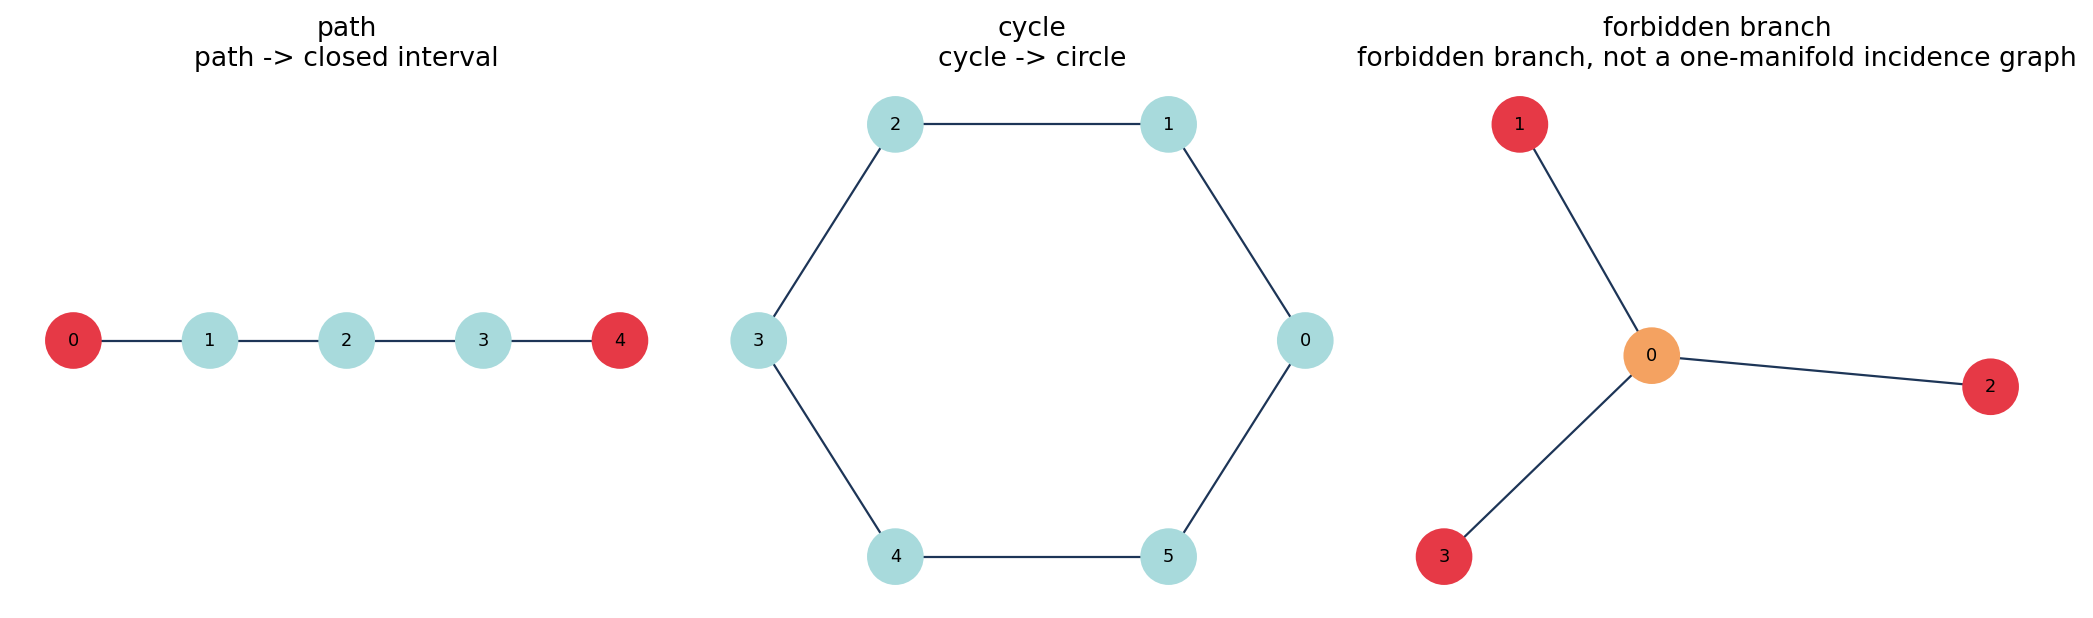

[{'model': 'path',
  'degrees': [1, 1, 2, 2, 2],
  'classification': 'path -> closed interval'},
 {'model': 'cycle',
  'degrees': [2, 2, 2, 2, 2, 2],
  'classification': 'cycle -> circle'},
 {'model': 'forbidden branch',
  'degrees': [1, 1, 1, 3],
  'classification': 'forbidden branch, not a one-manifold incidence graph'}]

In [5]:
def classify_connected_graph(G):
    if not nx.is_connected(G):
        return "disconnected union of components"
    degrees = [deg for _, deg in G.degree()]
    if max(degrees) > 2:
        return "forbidden branch, not a one-manifold incidence graph"
    ones = sum(deg == 1 for deg in degrees)
    twos = sum(deg == 2 for deg in degrees)
    if ones == 2 and ones + twos == len(degrees):
        return "path -> closed interval"
    if ones == 0 and twos == len(degrees):
        return "cycle -> circle"
    if len(G.nodes) == 1 and degrees == [0]:
        return "degenerate isolated point case"
    return "not a compact connected one-manifold pattern"

path_graph = nx.path_graph(5)
cycle_graph = nx.cycle_graph(6)
branch_graph = nx.Graph([(0,1), (0,2), (0,3)])
graphs = [(path_graph, "path"), (cycle_graph, "cycle"), (branch_graph, "forbidden branch")]
classification_rows = []
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (Gmodel, label) in zip(axes, graphs):
    if label == "cycle":
        pos = nx.circular_layout(Gmodel)
    elif label == "path":
        pos = {n: (n, 0) for n in Gmodel.nodes}
    else:
        pos = nx.spring_layout(Gmodel, seed=7)
    node_colors = ["#e63946" if Gmodel.degree(n) == 1 else ("#f4a261" if Gmodel.degree(n) > 2 else "#a8dadc") for n in Gmodel.nodes]
    nx.draw_networkx(Gmodel, pos=pos, ax=ax, node_color=node_colors, edge_color="#1d3557", with_labels=True, node_size=600, font_size=8)
    result = classify_connected_graph(Gmodel)
    ax.set_title(f"{label}\n{result}")
    ax.axis("off")
    classification_rows.append({"model": label, "degrees": sorted([deg for _, deg in Gmodel.degree()]), "classification": result})
fig.tight_layout()
classifier_path = save_matplotlib(fig, FIGURES / "chain-cycle-forbidden-branch-classifier.png")
plt.close(fig)
classifier_csv = save_csv(classification_rows, TABLES / "chain-cycle-forbidden-branch-classifier.csv")
classifier_json = save_json({"rows": classification_rows}, CHECKS / "chain-cycle-forbidden-branch-classifier.json")
TRACKED_ARTIFACTS.extend([classifier_path, classifier_csv, classifier_json])
display_artifact(classifier_path, width=900)
classification_rows


## Applied Lab: From Smooth Cuts To Diffeomorphism Type

The appendix can be read as a pipeline. Choose a Morse function. Collect boundary and critical points into a finite set `S`. Remove `S`; the complement is a finite union of open intervals. Each interval component maps monotonically to an open interval. Record which endpoints in `S` lie in the closure of each component. The resulting incidence graph has degree at most two because a one-manifold has no branch-point local model. Connectivity then forces a path or a cycle. Finally, smooth the assembled coordinate so the path is diffeomorphic to a closed interval or the cycle is diffeomorphic to a circle.

This pipeline is also a warning about overgeneralizing pictures. A three-armed graph is compact and one-dimensional as a graph, but it is not a one-manifold because the central point has no neighborhood like a line or half-line. The graph classifier makes that failure visible as degree three.


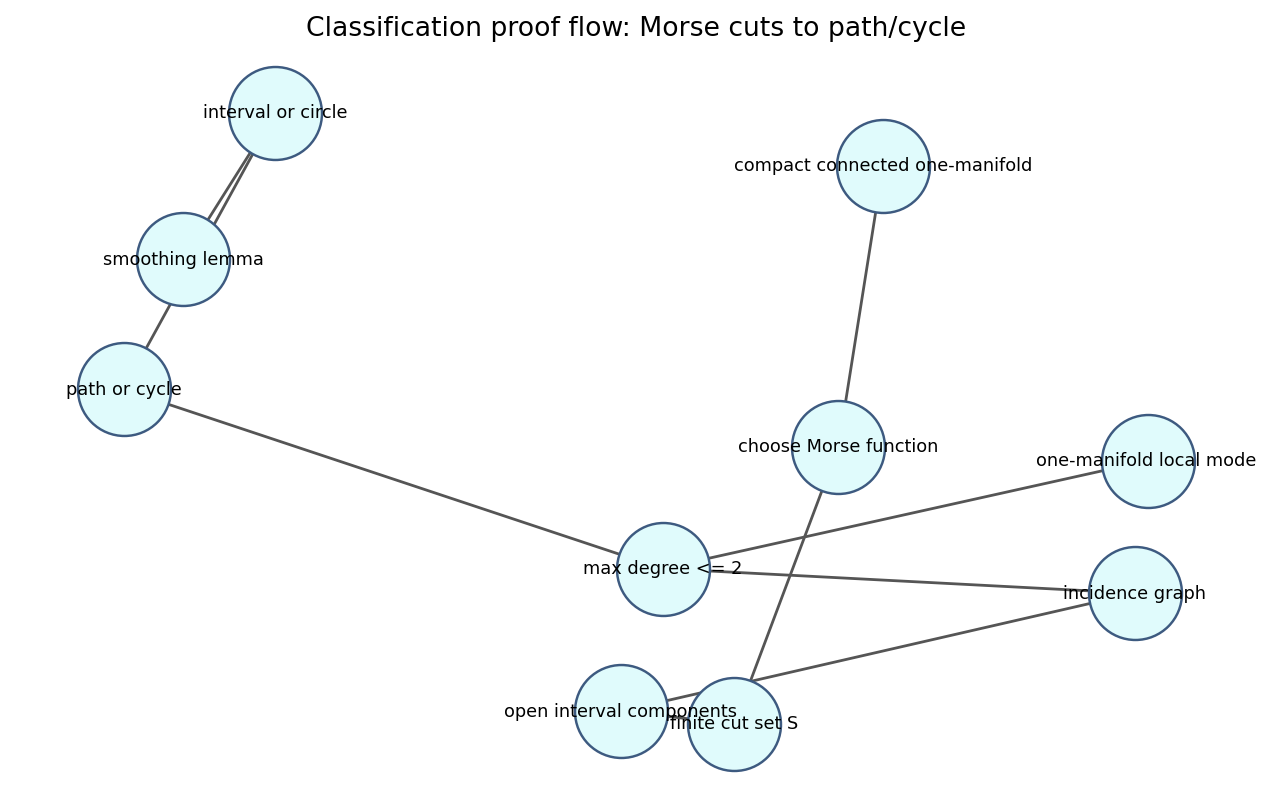

{'nodes': 10, 'edges': 9, 'acyclic': True}

In [6]:
G = nx.DiGraph()
edges = [
    ("compact connected one-manifold", "choose Morse function"),
    ("choose Morse function", "finite cut set S"),
    ("finite cut set S", "open interval components"),
    ("open interval components", "incidence graph"),
    ("one-manifold local model", "max degree <= 2"),
    ("incidence graph", "max degree <= 2"),
    ("max degree <= 2", "path or cycle"),
    ("path or cycle", "interval or circle"),
    ("smoothing lemma", "interval or circle"),
]
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=64, k=0.9)
fig, ax = plt.subplots(figsize=(10, 6))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", edge_color="#555555", width=1.25)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#e0fbfc", edgecolors="#3d5a80", linewidths=1.1, node_size=1750)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Classification proof flow: Morse cuts to path/cycle")
ax.axis("off")
dep_path = save_matplotlib(fig, FIGURES / "compact-one-manifold-classification-proof-flow.png")
plt.close(fig)
dep_json = save_json({"nodes": list(G.nodes), "edges": edges, "acyclic": nx.is_directed_acyclic_graph(G), "classification_reachable": nx.has_path(G, "compact connected one-manifold", "interval or circle")}, CHECKS / "compact-one-manifold-classification-proof-flow.json")
TRACKED_ARTIFACTS.extend([dep_path, dep_json])
display_artifact(dep_path, width=780)
{"nodes": G.number_of_nodes(), "edges": G.number_of_edges(), "acyclic": nx.is_directed_acyclic_graph(G)}


In [7]:
assert smooth_check["strictly_positive"] and smooth_check["monotone"]
assert smooth_check["endpoint_residual"] < 1e-10
assert all(row["open_interval_components"] <= row["cut_points"] for row in cut_rows)
assert component_check["monotone"] and component_check["minimum_derivative"] > 0
class_by_model = {row["model"]: row["classification"] for row in classification_rows}
assert class_by_model["path"] == "path -> closed interval"
assert class_by_model["cycle"] == "cycle -> circle"
assert "forbidden" in class_by_model["forbidden branch"]
assert nx.has_path(G, "compact connected one-manifold", "interval or circle")
assert_artifacts(TRACKED_ARTIFACTS, min_bytes=80)
final_sanity = {
    "unit": UNIT_KEY,
    "tracked_artifacts": len(TRACKED_ARTIFACTS),
    "core_checks": ["positive smoothing derivative", "finite Morse cut inventory", "component coordinate monotone", "path/cycle/branch graph classification", "proof-flow reachability"],
}
final_sanity


{'unit': 'appendix-2-classification-of-compact-one-manifolds',
 'tracked_artifacts': 12,
 'core_checks': ['positive smoothing derivative',
  'finite Morse cut inventory',
  'component coordinate monotone',
  'path/cycle/branch graph classification',
  'proof-flow reachability']}

## Takeaways

The compact one-manifold classification is a smooth theorem with a finite combinatorial heart. Morse cuts reduce the manifold to interval components. The local one-manifold model forbids branching, so the incidence graph has degree at most two. A connected finite graph with that degree constraint is a path or a cycle. Paths give closed intervals; cycles give circles. The smoothing lemma repairs the assembled coordinate so the classification is smooth rather than merely topological or piecewise smooth.

This appendix supports Chapter 2's parity arguments: compact one-manifolds have boundary points in pairs because interval components contribute two endpoints and circle components contribute none. That simple endpoint count is one of the engines behind mod two intersection theory.
